# WS02: Data Modeling Approaches

## Overview
This workshop explores two fundamental approaches to data modeling in FIWARE:

1. **Object-Oriented Approach**: Model real-world objects (rooms, sensors, actuators) as individual entities with their own properties and relationships.

2. **Hierarchical Approach**: Model only upper-level objects (e.g., locations/rooms) as entities; represent sensors and actuators as properties/attributes of those entities.

## Learning Objectives
- Understand the pros and cons of each approach
- Implement both models for the intelligent building use case
- Compare ease of specific queries (e.g., reading CO2 levels)
- Evaluate impact of changes (e.g., replacing sensors)
- Assess adaptability to new requirements (e.g., adding occupancy sensors)

## Use Case Reminder

We are digitizing an intelligent building with:
- 1 office building
- 3 floors
- 10 office rooms per floor
- Each office room contains following devices:

| Sensors | Actuators |
| :--- | :--- |
| Temperature sensor | Air ventilation unit |
| CO2 sensor | Fan coil unit |

## Setup

In [6]:
# Import required packages
import logging
import json
import time
from mqtt_client import N5gehMQTTClient
from pydantic import ConfigDict, BaseModel, Field
from filip.clients.ngsi_v2 import ContextBrokerClient
from filip.models.ngsi_v2.context import (
    ContextEntity,
    ContextAttribute,
    NamedContextAttribute,
    ContextEntityKeyValues,
)
from filip.utils.cleanup import clear_context_broker
from utils import FiwareHeaderSecure

# Configure logging
logging.basicConfig(
    level="INFO",
    format="%(asctime)s %(name)s %(levelname)s: %(message)s",
    datefmt="%d-%m-%Y %H:%M:%S",
)
logger = logging.getLogger(__name__)

# Configuration
CB_URL = "https://n5geh.eonerc.rwth-aachen.de/orion/"
SERVICE = "n5geh_demo"
SERVICE_PATH_OO = "/object_oriented"
SERVICE_PATH_HIER = "/hierarchical"
fiware_header_oo = FiwareHeaderSecure(service=SERVICE, service_path=SERVICE_PATH_OO)
fiware_header_h = FiwareHeaderSecure(service=SERVICE,service_path=SERVICE_PATH_HIER)
cb_client_oo = ContextBrokerClient(url=CB_URL, fiware_header=fiware_header_oo)
clear_context_broker(cb_client=cb_client_oo)
cb_client_h = ContextBrokerClient(url=CB_URL, fiware_header=fiware_header_h)
clear_context_broker(cb_client=cb_client_h)

print("Setup completed successfully!")

D:\anaconda3\envs\n5gehworkshop\Lib\site-packages\pydantic\_internal\_fields.py:201: UserWarning: Field name "json" in "HttpCustom" shadows an attribute in parent "Http"
  warnings.warn(
D:\anaconda3\envs\n5gehworkshop\Lib\site-packages\pydantic\_internal\_fields.py:201: UserWarning: Field name "json" in "MqttCustom" shadows an attribute in parent "Mqtt"
  warnings.warn(


Fetching new token for service...
Fetching new token for service...
Setup completed successfully!


## Part 1: Object-Oriented Approach

In this approach, each physical object (room, sensor, actuator) is modeled as a separate entity. This allows fine-grained control and flexibility but requires more entities.

### 1.1 Define Use-Case Specific Models (Object-Oriented Approach)

Following the pattern from e12_ngsi_v2_use_case_models.py, we first define simple, use-case specific models that are independent of FIWARE. These can be reused in other systems.

In [7]:
# First, define simple use-case models (independent of FIWARE)

# Room model - simple and reusable
class RoomOO(BaseModel):
    """Simple Room model for object-oriented approach"""
    model_config = ConfigDict(populate_by_name=True)

    floor: int = Field(description="Floor number")
    room_number: int = Field(alias="roomNumber", description="Room number on the floor")
    location: str = Field(description="Building location/section")


# Temperature Sensor model - simple and reusable
class TemperatureSensorOO(BaseModel):
    """Simple Temperature Sensor model"""
    model_config = ConfigDict(populate_by_name=True)

    temperature: float = Field(description="Current temperature in Celsius")
    sensor_model: str = Field(alias="sensorModel", description="Sensor model")
    location: str = Field(description="Physical location")


# CO2 Sensor model - simple and reusable
class CO2SensorOO(BaseModel):
    """Simple CO2 Sensor model"""
    model_config = ConfigDict(populate_by_name=True)

    co2_level: float = Field(alias="co2Level", description="CO2 level in ppm")
    sensor_model: str = Field(alias="sensorModel", description="Sensor model")
    location: str = Field(description="Physical location")


# Humidity Sensor model - simple and reusable
class HumiditySensorOO(BaseModel):
    """Simple Humidity Sensor model"""
    model_config = ConfigDict(populate_by_name=True)

    humidity: float = Field(description="Humidity level in percentage")
    sensor_model: str = Field(alias="sensorModel", description="Sensor model")
    location: str = Field(description="Physical location")


print("Use-case models defined successfully!")

Use-case models defined successfully!


### 1.2 Define FIWARE-Compatible Entity Models (Object-Oriented Approach)

Now we merge the use-case models with FIWARE's ContextEntityKeyValues to create FIWARE-compatible entities.

In [8]:
# Merge with FIWARE models to ensure compatibility

class RoomOOFIWARE(RoomOO, ContextEntityKeyValues):
    """Room entity for object-oriented approach - FIWARE compatible"""
    type: str = "Room"


class TemperatureSensorFIWARE(TemperatureSensorOO, ContextEntityKeyValues):
    """Temperature Sensor entity - FIWARE compatible"""
    type: str = "TemperatureSensor"


class CO2SensorFIWARE(CO2SensorOO, ContextEntityKeyValues):
    """CO2 Sensor entity - FIWARE compatible"""
    type: str = "CO2Sensor"


print("FIWARE-compatible entity models defined successfully!")

FIWARE-compatible entity models defined successfully!


### 1.3 Create and Query Entities (Object-Oriented Approach)

In [9]:
# Example: Create a room and sensors in object-oriented approach
room_oo = RoomOOFIWARE(
    id="Room101",
    floor=1,
    room_number=101,
    location="Building A"
)

# Create temperature sensor for the room
temp_sensor = TemperatureSensorFIWARE(
    id="Room101_TempSensor",
    temperature=22.5,
    sensor_model="PT100",
    location=room_oo.id
)

# Create co2 sensor for the room
co2_sensor = CO2SensorFIWARE(
    id="Room101_CO2Sensor",
    co2_level=450.0,
    sensor_model="MH-Z19",
    location=room_oo.id
)

# Post the entities to the Context Broker
cb_client_oo.post_entity(entity=room_oo, key_values=True, update=True)
cb_client_oo.post_entity(entity=temp_sensor, key_values=True, update=True)
cb_client_oo.post_entity(entity=co2_sensor, key_values=True, update=True)

14-04-2026 15:09:58 ContextBrokerClient INFO: Entity successfully posted!
14-04-2026 15:09:59 ContextBrokerClient INFO: Entity successfully posted!
14-04-2026 15:09:59 ContextBrokerClient INFO: Entity successfully posted!


'/v2/entities/Room101_CO2Sensor?type=CO2Sensor'

Let's verify the entities were created successfully

In [10]:
# Get the room entity
retrieved_room = cb_client_oo.get_entity(entity_id=room_oo.id, response_format="keyValues")
print(f"Retrieved entity {retrieved_room.id}:\n{retrieved_room.model_dump_json(indent=2)}")
retrieved_temp_sensor = cb_client_oo.get_entity(entity_id=temp_sensor.id, response_format="keyValues")
print(f"Retrieved entity {retrieved_temp_sensor.id}:\n{retrieved_temp_sensor.model_dump_json(indent=2)}")
retrieved_co2 = cb_client_oo.get_entity(entity_id=co2_sensor.id, response_format="keyValues")
print(f"Retrieved entity {retrieved_co2.id}:\n{retrieved_co2.model_dump_json(indent=2)}")

14-04-2026 15:09:59 ContextBrokerClient INFO: Entity successfully retrieved!
14-04-2026 15:09:59 ContextBrokerClient INFO: Entity successfully retrieved!
14-04-2026 15:09:59 ContextBrokerClient INFO: Entity successfully retrieved!


Retrieved entity Room101:
{
  "id": "Room101",
  "type": "Room",
  "floor": 1,
  "location": "Building A",
  "room_number": 101
}
Retrieved entity Room101_TempSensor:
{
  "id": "Room101_TempSensor",
  "type": "TemperatureSensor",
  "location": "Room101",
  "sensor_model": "PT100",
  "temperature": 22.5
}
Retrieved entity Room101_CO2Sensor:
{
  "id": "Room101_CO2Sensor",
  "type": "CO2Sensor",
  "co2_level": 450,
  "location": "Room101",
  "sensor_model": "MH-Z19"
}


### 1.4 Reuse the data models in applications

In applications, we can use the datamodels to instantiate objects that hold the data retrieved from the platform. This allows us to work with consistent data structures in different applications. Below is an example to parse the retrieved room entity into a Room object and access its attributes.

In [11]:
room = RoomOO.model_validate(retrieved_room.model_dump())
print("As an application, we can now use the room object:")
print("The floor of the room is:", room.floor)
print("The room number of the room is:", room.room_number)
print("The location of the room is:", room.location)

As an application, we can now use the room object:
The floor of the room is: 1
The room number of the room is: 101
The location of the room is: Building A


### 1.5 Data model based sensor provisioning

The data models can also be used to automatically provision sensors.
In this example, we will use the Entirety to load the data model of the temperature sensor and configure an automatic provisioning.
A demonstration instance of the Entirety is available at https://entirety.eonerc.rwth-aachen.de/ (login with username: admin, password: admin).
We need to first export the data model of the temperature sensor into a JSON-schema.

In [12]:
print(json.dumps(TemperatureSensorFIWARE.model_json_schema(), indent=2))

{
  "additionalProperties": true,
  "description": "Temperature Sensor entity - FIWARE compatible",
  "properties": {
    "id": {
      "description": "Id of an entity in an NGSI context broker. Allowed characters are the ones in the plain ASCII set, except the following ones: control characters, whitespace, &, ?, / and #.",
      "example": "Bcn-Welt",
      "maxLength": 256,
      "minLength": 1,
      "title": "Entity Id",
      "type": "string"
    },
    "type": {
      "default": "TemperatureSensor",
      "title": "Type",
      "type": "string"
    },
    "temperature": {
      "description": "Current temperature in Celsius",
      "title": "Temperature",
      "type": "number"
    },
    "sensorModel": {
      "description": "Sensor model",
      "title": "Sensormodel",
      "type": "string"
    },
    "location": {
      "description": "Physical location",
      "title": "Location",
      "type": "string"
    }
  },
  "required": [
    "id",
    "temperature",
    "sensorMode

Then we can save the JSON-schema in **Data Models** module with the name `TemperatureSensor`.

<img src="./images/load.png" alt="Load Data Model" width="300">

Afterward, we can create a device service group that inherits from the `TemperatureSensor` data model. By activating the auto-provisioning function, new detected sensors will be automatically provisioned with the defined data model.
**Please make sure that the `API Key` is set to `entirety`, as this is essential for the MQTT communication.**

<img src="./images/create_service_group.png" alt="Load Data Model" width="300">

Now we can emulate a new temperature sensor by sending messages to the MQTT broker of the platform. We will see that new entities are automatically created in the Context Broker with the defined data model.
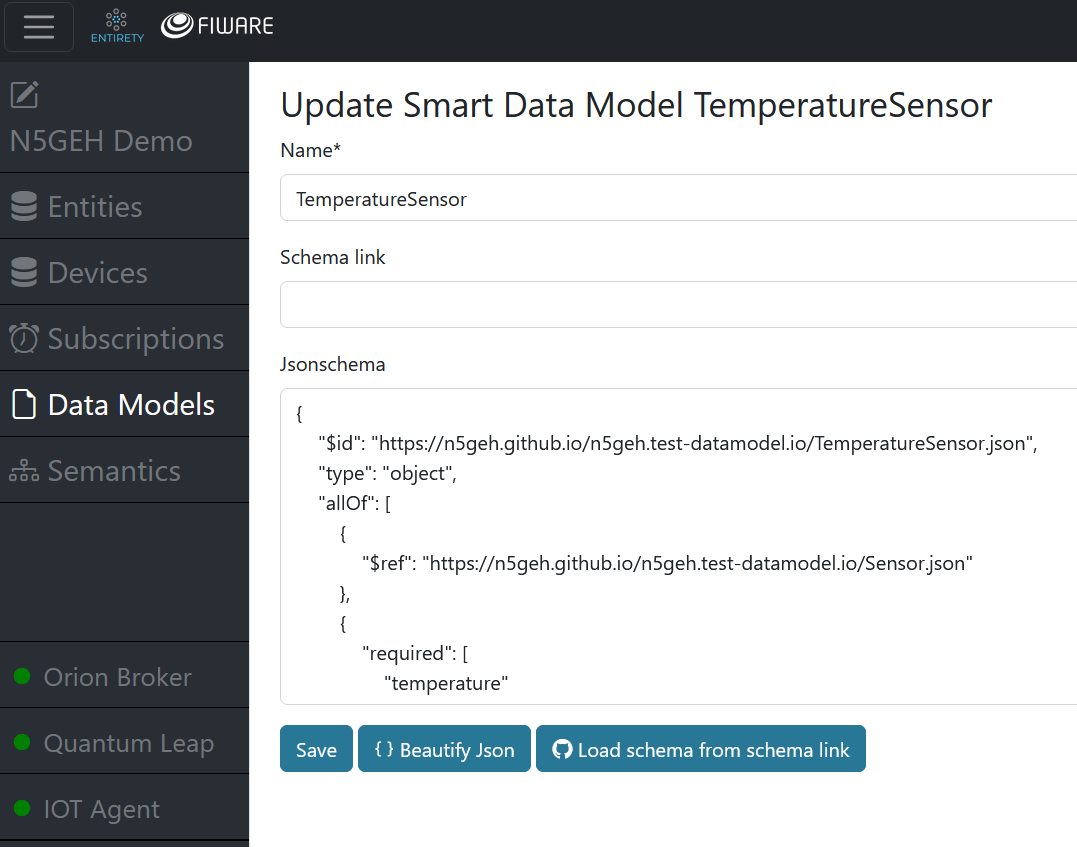

In [25]:
mqtt_client = N5gehMQTTClient()
apikey = "entirety"  # as configured in the service group
device_id = "temp:001"  # you can change the id
mqtt_client.publish(
    topic=f"/json/{apikey}/{device_id}/attrs",
    msg=json.dumps({
        "temperature": 25
    })
)
time.sleep(1)

Let's verify that the new sensor is created in the Context Broker with the correct data model.

In [26]:
fiware_header_entirety = FiwareHeaderSecure(service="n5geh_demo", service_path="/")
fiware_header_entirety.service = "entirety"
cb_client_entirety = ContextBrokerClient(url=CB_URL, fiware_header=fiware_header_entirety)
new_temp_sensor = cb_client_entirety.get_entity_list(entity_types=["TemperatureSensor"], q="temperature>=25", response_format="keyValues")
# TODO other attributes are not updated.
print(f"Newly provisioned temperature sensor:\n{new_temp_sensor[0].model_dump_json(indent=2)}")

Fetching new token for service...
Newly provisioned temperature sensor:
{
  "id": "TemperatureSensor:temp:001",
  "type": "TemperatureSensor",
  "TimeInstant": "2026-04-14T13:11:26.442Z",
  "temperature": 25
}


## Part 2: Hierarchical Approach

In this approach, we model only the room as an entity, and represent sensors/actuators as attributes or sub-attributes of the room. This reduces the number of entities but requires handling nested data structures.


### 2.1 Define Use-Case Specific Models

In [15]:
# Define sensor data models as structured values (like PostalAddress pattern)

# Temperature Sensor as a structured attribute
class TemperatureSensorData(BaseModel):
    """Temperature Sensor data - reusable structured model"""
    model_config = ConfigDict(populate_by_name=True)

    temperature: float = Field(description="Current temperature in Celsius")
    sensor_model: str = Field(description="Sensor model")


# CO2 Sensor as a structured attribute
class CO2SensorData(BaseModel):
    """CO2 Sensor data - reusable structured model"""
    model_config = ConfigDict(populate_by_name=True)

    co2_level: float = Field(description="CO2 level in ppm")
    sensor_model: str = Field(description="Sensor model")


# Room with sensors as structured attributes
class RoomWithSensors(BaseModel):
    """Room with embedded sensor data - hierarchical approach"""
    model_config = ConfigDict(populate_by_name=True)

    floor: int = Field(description="Floor number")
    room_number: int = Field(description="Room number on the floor")
    location: str = Field(description="Building location/section")
    temperature_sensor: TemperatureSensorData = Field(alias="temperatureSensor", description="Temperature sensor data")
    co2_sensor: CO2SensorData = Field(description="CO2 sensor data")


print("Use-case models for hierarchical approach defined successfully!")

Use-case models for hierarchical approach defined successfully!


### 2.2 Define FIWARE-Compatible Entity Models

In [16]:
# Merge with FIWARE models to ensure compatibility

class RoomWithSensorsFIWARE(RoomWithSensors, ContextEntityKeyValues):
    """Room with embedded sensors - FIWARE compatible (hierarchical approach)"""
    type: str = "Room"

print("FIWARE-compatible entity model for hierarchical approach defined successfully!")

FIWARE-compatible entity model for hierarchical approach defined successfully!


### 2.3 Create and Query Entities (Hierarchical Approach)

In [17]:
# Example: Create a room with embedded sensors in hierarchical approach
room_hier = RoomWithSensorsFIWARE(
    id="urn:ngsi-ld:Room:Floor1_Room101_Hier",
    floor=1,
    room_number=101,
    location="Building A",
    temperature_sensor=TemperatureSensorData(
        temperature=22.5,
        sensor_model="PT100"
    ),
    co2_sensor=CO2SensorData(
        co2_level=450.0,
        sensor_model="MH-Z19"
    )
)

# Post the entity to the Context Broker
cb_client_h.post_entity(entity=room_hier, key_values=True, update=True)

14-04-2026 15:10:00 ContextBrokerClient INFO: Entity successfully posted!


'/v2/entities/urn:ngsi-ld:Room:Floor1_Room101_Hier?type=Room'

Let's verify the entity was created successfully.

In [18]:
retrieved_room_hier = cb_client_h.get_entity(entity_id=room_hier.id, response_format="keyValues")
print(f"Retrieved entity {retrieved_room_hier.id}:\n{retrieved_room_hier.model_dump_json(indent=2)}")

14-04-2026 15:10:01 ContextBrokerClient INFO: Entity successfully retrieved!


Retrieved entity urn:ngsi-ld:Room:Floor1_Room101_Hier:
{
  "id": "urn:ngsi-ld:Room:Floor1_Room101_Hier",
  "type": "Room",
  "co2_sensor": {
    "co2_level": 450,
    "sensor_model": "MH-Z19"
  },
  "floor": 1,
  "location": "Building A",
  "room_number": 101,
  "temperature_sensor": {
    "temperature": 22.5,
    "sensor_model": "PT100"
  }
}


## Part 3: Comparison and Analysis
In this section, we will perform some tasks with both data modelling approaches and analyze their differences.
1. Check the CO2 level
2. Replace defective temperature sensor
3. Add new occupancy sensor


### 3.1 Check CO2 level for a specific room
The two modelling approaches require different steps to retrieve the CO2 level for a specific room.

- Object-Oriented:
    - Query all CO2Sensor entities
    - Filter by location to find the relevant sensor id
    - Query the CO2 level from that sensor entity
- Hierarchical:
    - Query the Room entity with the relevant id
    - Parse the CO2 level from the co2Sensor attribute

In [19]:
# check for object-oriented approach
co2_sensors = cb_client_oo.get_entity_list(entity_types=["CO2Sensor"], response_format="keyValues")
co2_sensor_101 = next((sensor for sensor in co2_sensors if sensor.location == room_oo.id), None)
co2_value_oo = co2_sensor_101.co2_level
print(f"CO2 level in Room101 (object-oriented): {co2_value_oo} ppm")

# check for hierarchical approach
room_hier_101 = cb_client_h.get_entity(entity_id=room_hier.id, response_format="keyValues")
co2_value_h = room_hier_101.co2_sensor["co2_level"]
print(f"CO2 level in Room101 (hierarchical): {co2_value_h} ppm")

14-04-2026 15:10:01 ContextBrokerClient INFO: Entity successfully retrieved!


CO2 level in Room101 (object-oriented): 450 ppm
CO2 level in Room101 (hierarchical): 450 ppm


Seems like the hierarchical approach allows us to retrieve the CO2 level with fewer queries and simpler logic. But what if the task is now to check the average CO2 level across all rooms?

In [20]:
# TODO try to implement the logic for both approaches


### 3.2 Replace defective temperature sensor

In case of a defective temperature sensor, we need to replace it with a new one. The steps for each approach would be:
- Object-Oriented:
    - Create a new TemperatureSensor entity with the same location but updated sensor model and values
    - Delete the old TemperatureSensor entity
- Hierarchical:
    - Update the temperatureSensor attribute of the Room entity with the new sensor model and values


In [21]:
# Replace sensor for object-oriented approach
temp_sensor_new = TemperatureSensorFIWARE(
    id="Room101_TempSensor_New",
    sensor_model="PT1000",
    temperature=22.5,
    location=room_oo.id
)
cb_client_oo.post_entity(entity=temp_sensor_new, key_values=True)
print(f"New sensor entity created: {temp_sensor_new.id}")
cb_client_oo.delete_entity(entity_id=temp_sensor.id)
print(f"Old sensor entity deleted: {temp_sensor.id}")

# check for hierarchical approach
room_hier_101 = cb_client_h.get_entity(entity_id=room_hier.id, response_format="keyValues")
room_hier_101.temperature_sensor["sensor_model"] = "PT1000"
cb_client_h.override_entity(
    entity=room_hier_101,
    key_values=True,
)
print("Sensor information in room entity updated")

14-04-2026 15:10:01 ContextBrokerClient INFO: Entity successfully posted!


New sensor entity created: Room101_TempSensor_New


14-04-2026 15:10:01 ContextBrokerClient INFO: Entity 'Room101_TempSensor' successfully deleted!
14-04-2026 15:10:01 ContextBrokerClient INFO: Entity successfully retrieved!


Old sensor entity deleted: Room101_TempSensor


14-04-2026 15:10:01 ContextBrokerClient INFO: Entity 'urn:ngsi-ld:Room:Floor1_Room101_Hier' successfully updated!


Sensor information in room entity updated


While the object-oriented approach seems to require more steps to replace a sensor, what is the advantage of it?
> Hint: How would you handle the data communication with the new sensor?

### 3.3 Add new occupancy sensor
Now we want to install new occupancy sensors to our room. Since the occupancy sensor was not part of our original data model, we need to add it now.
The steps would be as follows.

- Object-Oriented:
  - Create data model for occupancy sensor
  - Create new sensor entity and link it to the room
- Hierarchical:
  - Create data structure for occupancy sensor
  - Update the Room data model
  - Update the room entity correspondingly

In [22]:
# object-oriented approach
# Define data model for occupancy sensor
class OccupancySensor(BaseModel):
    """Occupancy Sensor data - reusable structured model"""
    model_config = ConfigDict(populate_by_name=True)
    occupancy: bool = Field(description="Occupancy status (True if occupied, False if not)")
    sensor_model: str = Field(description="Sensor model")
    location: str = Field(description="Location of the sensor, e.g. a room")

class OccupancySensorFIWARE(OccupancySensor, ContextEntityKeyValues):
    """Occupancy Sensor - hierarchical approach"""
    type: str = "OccupancySensor"

occupancy_sensor = OccupancySensorFIWARE(
    id="Room101_OccupancySensor",
    occupancy=True,
    sensor_model="PIR Sensor",
    location=room_oo.id
)
cb_client_oo.post_entity(entity=occupancy_sensor, key_values=True)

# hierarchical approach
# Define the data structure for occupancy sensor
class OccupancySensorData(BaseModel):
    """Occupancy Sensor data - reusable structured model"""
    model_config = ConfigDict(populate_by_name=True)
    occupancy: bool = Field(description="Occupancy status (True if occupied, False if not)")
    sensor_model: str = Field(description="Sensor model")

# Update the Room data model
class RoomWithSensorsWithOccupancy(BaseModel):
    """Room with embedded sensor data including occupancy - hierarchical approach"""
    model_config = ConfigDict(populate_by_name=True)

    floor: int = Field(description="Floor number")
    room_number: int = Field(description="Room number on the floor")
    location: str = Field(description="Building location/section")
    temperature_sensor: TemperatureSensorData = Field(alias="temperatureSensor", description="Temperature sensor data")
    co2_sensor: CO2SensorData = Field(description="CO2 sensor data")
    occupancy_sensor: OccupancySensorData = Field(description="Occupancy sensor data")

class RoomWithSensorsWithOccupancyFIWARE(RoomWithSensorsWithOccupancy, ContextEntityKeyValues):
    """Room with embedded sensors including occupancy - FIWARE compatible (hierarchical approach)"""
    type: str = "Room"

# Update the room entity
cb_client_h.delete_entity(entity_id=room_hier.id)
room_hier_occupancy = RoomWithSensorsWithOccupancyFIWARE(
    occupancy_sensor=OccupancySensorData(
        occupancy=True,
        sensor_model="PIR Sensor",
    ),
    **room_hier.model_dump()
)
cb_client_h.post_entity(entity=room_hier_occupancy, key_values=True)



14-04-2026 15:10:01 ContextBrokerClient INFO: Entity successfully posted!
14-04-2026 15:10:01 ContextBrokerClient INFO: Entity 'urn:ngsi-ld:Room:Floor1_Room101_Hier' successfully deleted!
14-04-2026 15:10:01 ContextBrokerClient INFO: Entity successfully posted!


'/v2/entities/urn:ngsi-ld:Room:Floor1_Room101_Hier?type=Room'

In this task, the flexibility of the object-oriented approach allows us to easily add a new sensor without modifying existing entities.
In contrast, the hierarchical approach requires us to update the current data model and the entire room entity, which is more complex and error-prone, especially if there are many rooms/entities to update.

## Summary

### Key Takeaways

1. **Object-Oriented Approach**:
   - Each physical object (room, sensor, actuator) is a separate entity
   - Provides maximum flexibility and granular control
   - More entities to manage
   - Better for scenarios with independent sensor management or complex sensor relationships

2. **Hierarchical Approach**:
   - Models only container entities (e.g., rooms)
   - Sensors/actuators are attributes of the container
   - Fewer entities to manage
   - Simpler queries and atomic updates
   - Better for scenarios where sensors are tightly coupled to their locations

3. **Practical Recommendation**:
   - For simple, tightly-coupled deployments: use **Hierarchical Approach**
   - For complex, distributed sensor systems: use **Object-Oriented Approach**
   - Most importantly, create clear and consistent data models for your IoT platform!